### Introduction to Regression with Neural Networks in TensorFlow

In [1]:
# Import TensorFlow
import tensorflow as tf 
print(tf.__version__)


2.15.0


### Creating data to view and fit

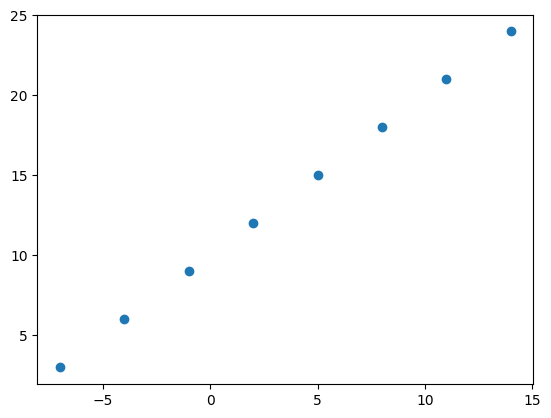

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y)

### Input and Output shapes

In [3]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [4]:
# Turn our Numpy arrays into tensors  with dtype float32
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [5]:
input_shape = X[0].shape 
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

### Steps in modelling with TensorFlow

In [6]:
# Set random seed
tf.random.set_seed(29)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae, # Mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)      


Epoch 1/5


1/1 [==============================] - 1s 848ms/step - loss: 17.1628 - mae: 17.1628
Epoch 2/5
1/1 [==============================] - 0s 7ms/step - loss: 16.8815 - mae: 16.8815
Epoch 3/5
1/1 [==============================] - 0s 5ms/step - loss: 16.6003 - mae: 16.6003
Epoch 4/5
1/1 [==============================] - 0s 5ms/step - loss: 16.3190 - mae: 16.3190
Epoch 5/5
1/1 [==============================] - 0s 7ms/step - loss: 16.0378 - mae: 16.0378


In [7]:
# Try and make a prediction using our model
model.predict([17.0])

1/1 [==============================] - 0s 119ms/step


array([[-9.789059]], dtype=float32)

## Improving our model

In [8]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 324ms/step - loss: 21.6732 - mae: 21.6732
Epoch 2/100
1/1 [==============================] - 0s 7ms/step - loss: 21.2800 - mae: 21.2800
Epoch 3/100
1/1 [==============================] - 0s 6ms/step - loss: 20.8869 - mae: 20.8869
Epoch 4/100
1/1 [==============================] - 0s 6ms/step - loss: 20.5098 - mae: 20.5098
Epoch 5/100
1/1 [==============================] - 0s 5ms/step - loss: 20.2286 - mae: 20.2286
Epoch 6/100
1/1 [==============================] - 0s 6ms/step - loss: 19.9473 - mae: 19.9473
Epoch 7/100
1/1 [==============================] - 0s 5ms/step - loss: 19.6661 - mae: 19.6661
Epoch 8/100
1/1 [==============================] - 0s 5ms/step - loss: 19.3848 - mae: 19.3848
Epoch 9/100
1/1 [==============================] - 0s 9ms/step - loss: 19.1036 - mae: 19.1036
Epoch 10/100
1/1 [==============================] - 0s 6ms/step - loss: 18.8223 - mae: 18.8223
Epoch 11/100
1/1 [==============================] - 0s 5m

In [9]:
# Let's see if our model's prediction has improved
model.predict([17.0])

1/1 [==============================] - 0s 79ms/step


array([[29.574017]], dtype=float32)

In [10]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
   tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 413ms/step - loss: 9.8304 - mae: 9.8304
Epoch 2/100
1/1 [==============================] - 0s 5ms/step - loss: 9.8259 - mae: 9.8259
Epoch 3/100
1/1 [==============================] - 0s 6ms/step - loss: 9.8214 - mae: 9.8214
Epoch 4/100
1/1 [==============================] - 0s 5ms/step - loss: 9.8169 - mae: 9.8169
Epoch 5/100
1/1 [==============================] - 0s 5ms/step - loss: 9.8124 - mae: 9.8124
Epoch 6/100
1/1 [==============================] - 0s 5ms/step - loss: 9.8079 - mae: 9.8079
Epoch 7/100
1/1 [==============================] - 0s 6ms/step - loss: 9.8034 - mae: 9.8034
Epoch 8/100
1/1 [==============================] - 0s 6ms/step - loss: 9.7989 - mae: 9.7989
Epoch 9/100
1/1 [==============================] - 0s 6ms/step - loss: 9.7944 - mae: 9.7944
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 9.7899 - mae: 9.7899
Epoch 11/100
1/1 [==============================] - 0s 5ms/step - loss: 9.785

In [11]:
model.predict([18.0])

1/1 [==============================] - 0s 81ms/step


array([[20.77228]], dtype=float32)

In [12]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 1s 545ms/step - loss: 13.6761 - mae: 13.6761
Epoch 2/100
1/1 [==============================] - 0s 5ms/step - loss: 13.0462 - mae: 13.0462
Epoch 3/100
1/1 [==============================] - 0s 6ms/step - loss: 12.4246 - mae: 12.4246
Epoch 4/100
1/1 [==============================] - 0s 5ms/step - loss: 11.8084 - mae: 11.8084
Epoch 5/100
1/1 [==============================] - 0s 6ms/step - loss: 11.1943 - mae: 11.1943
Epoch 6/100
1/1 [==============================] - 0s 6ms/step - loss: 10.5789 - mae: 10.5789
Epoch 7/100
1/1 [==============================] - 0s 6ms/step - loss: 9.9592 - mae: 9.9592
Epoch 8/100
1/1 [==============================] - 0s 5ms/step - loss: 9.3321 - mae: 9.3321
Epoch 9/100
1/1 [==============================] - 0s 7ms/step - loss: 8.6939 - mae: 8.6939
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 8.0413 - mae: 8.0413
Epoch 11/100
1/1 [==============================] - 0s 6ms/step -

In [13]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 80ms/step


array([[26.810753]], dtype=float32)

### Evaluating a model 

In practice, a typical workflow you'll go through when building neural networks is:

```
Built a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it.....
```

In [14]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X


<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [15]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

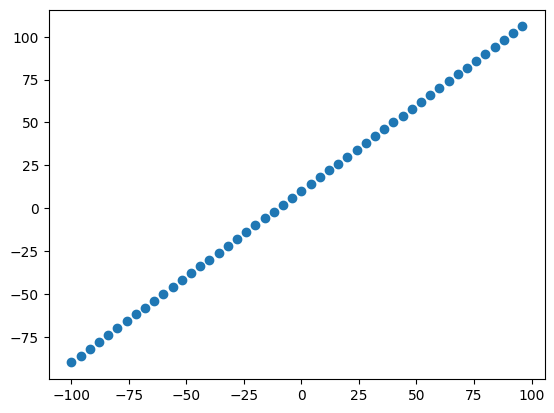

In [16]:
# Visualize the data 
import matplotlib.pyplot as plt

plt.scatter(X, y)

### The 3 sets...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data available.

In [17]:
# Check the length of how many samples we have
len(X)

50

In [18]:
# Split the data into train and test sets
X_train = X[:40] # First 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(X_test), len(y_test)

(40, 10, 10, 10)

### Visualizing the data
Now we've got our data in training and test sets...let's visualize it again!

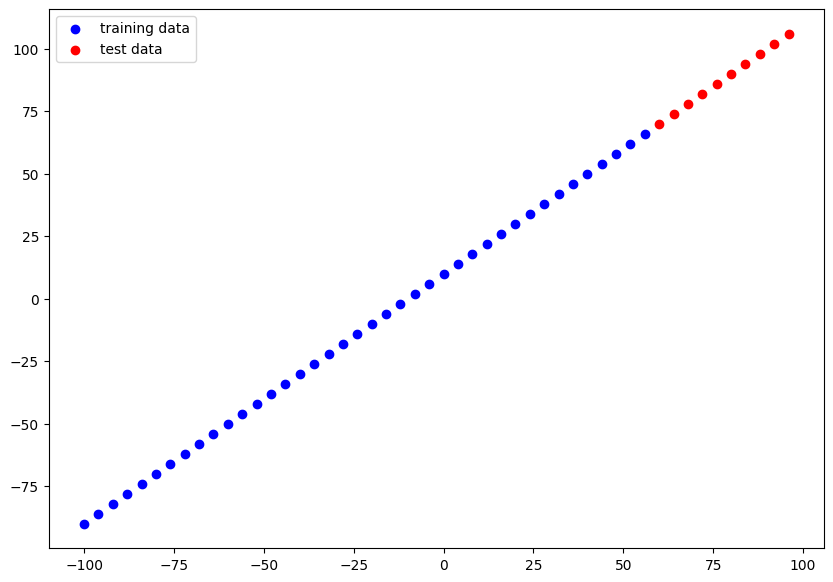

In [19]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="training data")

# Plot test data in red
plt.scatter(X_test, y_test, c="r", label="test data")

# Legend
plt.legend();

In [47]:
# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, input_shape=[1], name="input_shape"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [48]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_shape (Dense)         (None, 20)                40        
                                                                 
 output_layer (Dense)        (None, 1)                 21        
                                                                 
Total params: 61 (244.00 Byte)
Trainable params: 61 (244.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [49]:
# Let's fit the model with training data
model.fit(tf.expand_dims(X, -1), y, epochs=100, verbose=2)

Epoch 1/100
2/2 - 0s - loss: 45.5590 - mae: 45.5590 - 335ms/epoch - 167ms/step
Epoch 2/100
2/2 - 0s - loss: 24.9832 - mae: 24.9832 - 4ms/epoch - 2ms/step
Epoch 3/100
2/2 - 0s - loss: 34.0485 - mae: 34.0485 - 4ms/epoch - 2ms/step
Epoch 4/100
2/2 - 0s - loss: 31.5437 - mae: 31.5437 - 5ms/epoch - 2ms/step
Epoch 5/100
2/2 - 0s - loss: 9.9609 - mae: 9.9609 - 5ms/epoch - 2ms/step
Epoch 6/100
2/2 - 0s - loss: 18.6542 - mae: 18.6542 - 5ms/epoch - 2ms/step
Epoch 7/100
2/2 - 0s - loss: 29.9496 - mae: 29.9496 - 5ms/epoch - 3ms/step
Epoch 8/100
2/2 - 0s - loss: 19.9286 - mae: 19.9286 - 5ms/epoch - 2ms/step
Epoch 9/100
2/2 - 0s - loss: 10.3888 - mae: 10.3888 - 5ms/epoch - 3ms/step
Epoch 10/100
2/2 - 0s - loss: 32.4648 - mae: 32.4648 - 5ms/epoch - 3ms/step
Epoch 11/100
2/2 - 0s - loss: 16.7036 - mae: 16.7036 - 5ms/epoch - 3ms/step
Epoch 12/100
2/2 - 0s - loss: 29.4066 - mae: 29.4066 - 6ms/epoch - 3ms/step
Epoch 13/100
2/2 - 0s - loss: 24.7723 - mae: 24.7723 - 6ms/epoch - 3ms/step
Epoch 14/100
2/2 - 

In [50]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_shape (Dense)         (None, 20)                40        
                                                                 
 output_layer (Dense)        (None, 1)                 21        
                                                                 
Total params: 61 (244.00 Byte)
Trainable params: 61 (244.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


### Visualizing our model's predictions

To visualize predictions, it's a good idea to plot them against the ground truth labels.
Often you'll see this in the form of y_test, or y_true versus y_pred (ground truth versus your model's predictions).


In [52]:
# Make some predictions
y_pred = model.predict(X_test)
y_pred

1/1 [==============================] - 0s 116ms/step


array([[41.612812],
       [44.286564],
       [46.960316],
       [49.634075],
       [52.307827],
       [54.98158 ],
       [57.65533 ],
       [60.32909 ],
       [63.002842],
       [65.6766  ]], dtype=float32)

In [53]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

In [57]:
# Let's create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):

#Plots training data, test data and compares predictions to ground truth labels. 

    plt.figure(figsize=(10, 7))
    # plotting training data in blue
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    # Plot testing data in green
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    # Plot model's predictions in red
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    # Show the legend
    plt.legend();

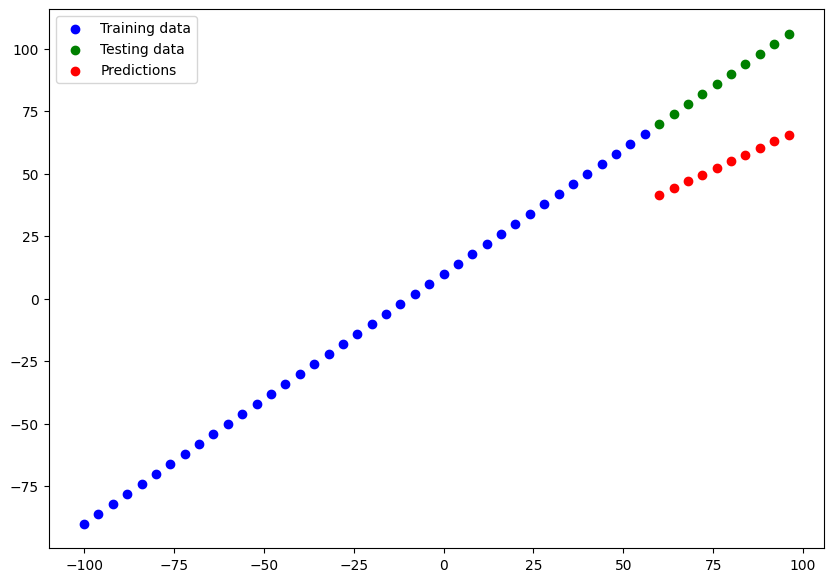

In [59]:
plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_pred)

### Evluating our model's predictions with regression evaluation metrics

Depending on the problem you're working on, there will be different evaluation metrics to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE - mean absolute error, "on average, how wrong is each of my model's predicitons"
* MSE - mean square error, "square the average errors"

In [60]:
# Evaluate the model on the test
model.evaluate(X_test, y_test)

1/1 [==============================] - 0s 197ms/step - loss: 34.3553 - mae: 34.3553


[34.35529708862305, 34.35529708862305]

In [62]:
# Calculate the mean absolute error 
mae = tf.metrics.mean_absolute_error(y_true=y_test,
                                     y_pred=tf.constant(y_pred))
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([46.387188, 43.713436, 41.039684, 38.365925, 35.692173, 33.01842 ,
       30.34467 , 27.67091 , 24.997158, 22.323402], dtype=float32)>

In [63]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[41.612812],
       [44.286564],
       [46.960316],
       [49.634075],
       [52.307827],
       [54.98158 ],
       [57.65533 ],
       [60.32909 ],
       [63.002842],
       [65.6766  ]], dtype=float32)>

In [64]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

In [65]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([41.612812, 44.286564, 46.960316, 49.634075, 52.307827, 54.98158 ,
       57.65533 , 60.32909 , 63.002842, 65.6766  ], dtype=float32)>

In [66]:
# Calculate the mean absolute error 
mae = tf.metrics.mean_absolute_error(y_true=y_test,
                                     y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=34.355297>

In [67]:
# Calculate the mean square error
mse = tf.metrics.mean_squared_error(y_true=y_test,
                                    y_pred=tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=1194.7976>

In [84]:
# Make some functions to reuse MAE and MSE

def mae(y_true, y_pred):
    return tf.metrics.mean_absolute_error(y_true=y_true,
                                          y_pred=tf.squeeze(y_pred))
    
def mse(y_true, y_pred):
    return tf.metrics.mean_squared_error(y_true=y_true,
                                         y_pred=tf.squeeze(y_pred))

### Running experiments to improve our model

1. Get more data = get more examples for your model to train on (more opportunities to learn patters or relationships between features and labels).

2. Make your model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.

3. Train for longer - give your model more of a chance to find patters in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layers, trained for 500 epochs

In [69]:
 X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56])>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66])>)

**Build model_1**

In [71]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# 3. Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 [==============================] - 0s 7ms/step - loss: 53.4597 - mae: 53.4597
Epoch 2/100
2/2 [==============================] - 0s 6ms/step - loss: 19.6917 - mae: 19.6917
Epoch 3/100
2/2 [==============================] - 0s 5ms/step - loss: 11.3049 - mae: 11.3049
Epoch 4/100
2/2 [==============================] - 0s 4ms/step - loss: 9.5689 - mae: 9.5689
Epoch 5/100
2/2 [==============================] - 0s 4ms/step - loss: 10.4763 - mae: 10.4763
Epoch 6/100
2/2 [==============================] - 0s 4ms/step - loss: 9.7037 - mae: 9.7037
Epoch 7/100
2/2 [==============================] - 0s 5ms/step - loss: 8.8005 - mae: 8.8005
Epoch 8/100
2/2 [==============================] - 0s 6ms/step - loss: 9.0749 - mae: 9.0749
Epoch 9/100
2/2 [==============================] - 0s 5ms/step - loss: 19.3056 - mae: 19.3056
Epoch 10/100
2/2 [==============================] - 0s 6ms/step - loss: 10.4308 - mae: 10.4308
Epoch 11/100
2/2 [==============================] - 0s 5ms/step - l

1/1 [==============================] - 0s 46ms/step


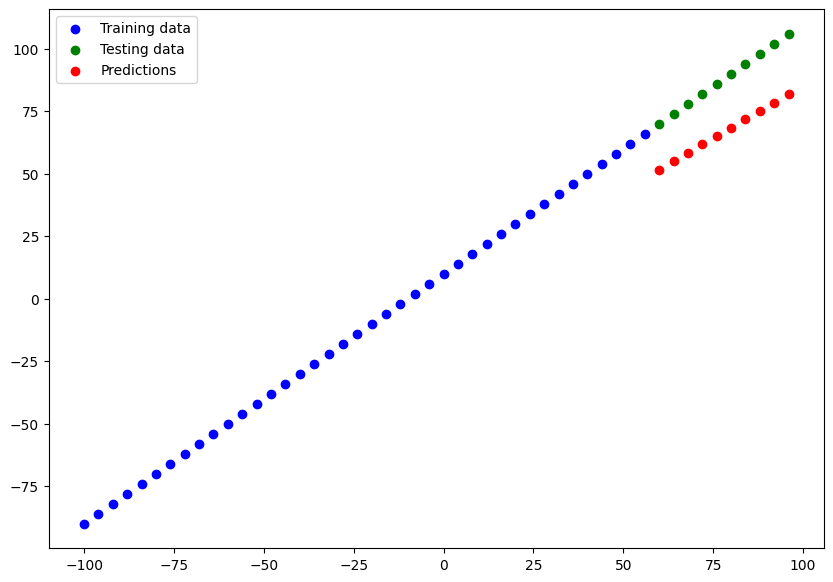

In [77]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [78]:
y_preds_1 = tf.squeeze(y_preds_1)

In [79]:
# Caclualte model_1 evaluation metrics
mae_1 = mae(y_test, y_preds_1)
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=21.251507>,
 <tf.Tensor: shape=(), dtype=float32, numpy=455.0501>)

**Build model_2**

In [74]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])

# 3. Fit the model
model_2.fit(tf.expand_dims(X_train,axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 [==============================] - 0s 9ms/step - loss: 26.8964 - mse: 1433.4264
Epoch 2/100
2/2 [==============================] - 0s 5ms/step - loss: 24.6633 - mse: 909.7485
Epoch 3/100
2/2 [==============================] - 0s 5ms/step - loss: 29.5045 - mse: 1294.8306
Epoch 4/100
2/2 [==============================] - 0s 5ms/step - loss: 15.9311 - mse: 382.7578
Epoch 5/100
2/2 [==============================] - 0s 6ms/step - loss: 21.8555 - mse: 696.2702
Epoch 6/100
2/2 [==============================] - 0s 7ms/step - loss: 11.4619 - mse: 148.4567
Epoch 7/100
2/2 [==============================] - 0s 6ms/step - loss: 12.5470 - mse: 207.3564
Epoch 8/100
2/2 [==============================] - 0s 4ms/step - loss: 11.0740 - mse: 147.2644
Epoch 9/100
2/2 [==============================] - 0s 5ms/step - loss: 39.6988 - mse: 2465.6665
Epoch 10/100
2/2 [==============================] - 0s 5ms/step - loss: 27.1910 - mse: 1040.1041
Epoch 11/100
2/2 [===========================

1/1 [==============================] - 0s 65ms/step


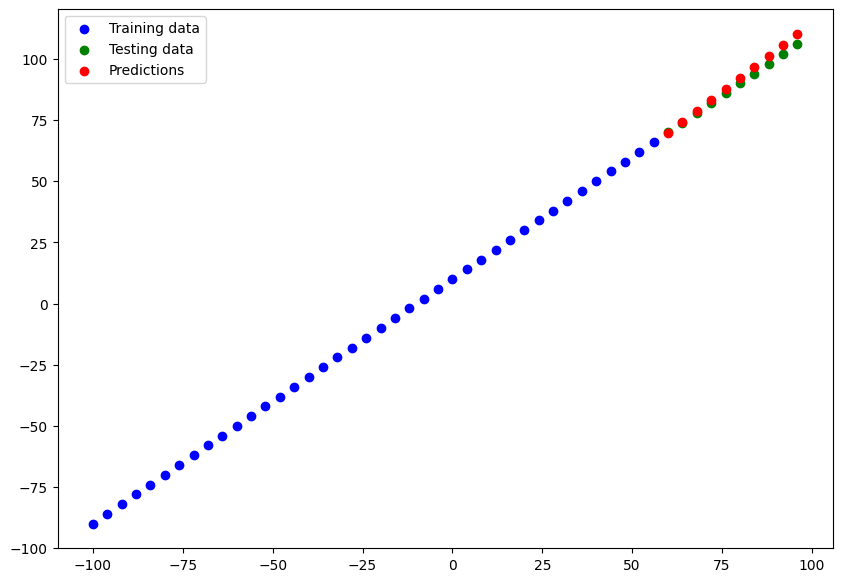

In [83]:
# Make and plot predictions of model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [85]:
# Calculte model_2 evaluation metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=2.0084236>,
 <tf.Tensor: shape=(), dtype=float32, numpy=5.9581475>)

**Build model_3**

In [87]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# 3. Fit the model
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500)

Epoch 1/500
2/2 [==============================] - 0s 6ms/step - loss: 47.9371 - mae: 47.9371
Epoch 2/500
2/2 [==============================] - 0s 5ms/step - loss: 14.4574 - mae: 14.4574
Epoch 3/500
2/2 [==============================] - 0s 5ms/step - loss: 20.4420 - mae: 20.4420
Epoch 4/500
2/2 [==============================] - 0s 5ms/step - loss: 13.1102 - mae: 13.1102
Epoch 5/500
2/2 [==============================] - 0s 3ms/step - loss: 14.3567 - mae: 14.3567
Epoch 6/500
2/2 [==============================] - 0s 6ms/step - loss: 11.4441 - mae: 11.4441
Epoch 7/500
2/2 [==============================] - 0s 4ms/step - loss: 12.4620 - mae: 12.4620
Epoch 8/500
2/2 [==============================] - 0s 5ms/step - loss: 10.9513 - mae: 10.9513
Epoch 9/500
2/2 [==============================] - 0s 4ms/step - loss: 38.8100 - mae: 38.8100
Epoch 10/500
2/2 [==============================] - 0s 3ms/step - loss: 26.4157 - mae: 26.4157
Epoch 11/500
2/2 [==============================] - 0s 5ms/

1/1 [==============================] - 0s 103ms/step


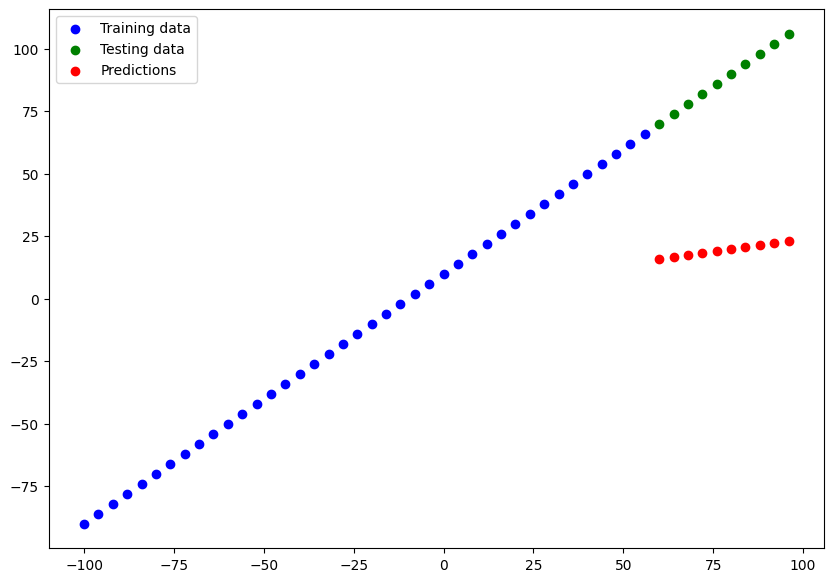

In [88]:
# Make and plot same predictions
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [89]:
# Calculate model_3 evaluation metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=68.425285>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4767.79>)

### Comparing the results of our experiments
We've run a few experiments, let's compare the results

In [96]:
# let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,21.251507,455.050110
1,model_2,2.008424,5.958148
2,model_3,68.425285,4767.790039


In [92]:
model_2.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 10)                20        
                                                                 
 dense_14 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Saving our models

In [93]:
# Save model using the SavedModel format
model_2.save("best_model_SavedModel_format")

INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


In [94]:
# Save model using the HDF5 format
model_2.save("best_model_HDF5_format.h5")

c:\Users\Priyesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Loading in a saved model

In [99]:
# Load in the SavedModel format model
loaded_SavedModel_format = tf.keras.models.load_model("best_model_SavedModel_format")
loaded_SavedModel_format.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 10)                20        
                                                                 
 dense_14 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [100]:
model_2.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 10)                20        
                                                                 
 dense_14 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [101]:
# Compare model_2 predictions with SavedModel format model predictions
model_2_preds = model_2.predict(X_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(X_test)

model_2_preds.squeeze() == loaded_SavedModel_format_preds.squeeze()

1/1 [==============================] - 0s 59ms/step


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [102]:
mae(y_true=y_test, y_pred=model_2_preds) == mae(y_true=y_test, y_pred=loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [104]:
# Load in a model using the .h5 format
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 10)                20        
                                                                 
 dense_14 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [105]:
model_2.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 10)                20        
                                                                 
 dense_14 (Dense)            (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [106]:
# Check to see if loaded .h5 model predictions match model_2
model_2_preds = model_2.predict(X_test)
loaded_h5_model_preds = loaded_h5_model.predict(X_test)
model_2_preds == loaded_h5_model_preds

1/1 [==============================] - 0s 78ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### A larger example 

In [1]:
# Import required libraries
import tensorflow as tf 
import pandas as pd 
import matplotlib.pyplot as plt 

In [18]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Data Preprocessing 

In [20]:
# Converting objects into numbers
insurance.sex = insurance.sex.apply(lambda x : 1 if x == "male" else 0)
insurance.sex

0       0
1       1
2       1
3       1
4       1
       ..
1333    1
1334    0
1335    0
1336    0
1337    0
Name: sex, Length: 1338, dtype: int64

In [21]:
insurance.smoker = insurance.smoker.apply(lambda x : 1 if x == "yes" else 0)
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [22]:
insurance.sex.unique(), insurance.smoker.unique()

(array([0, 1], dtype=int64), array([1, 0], dtype=int64))

In [24]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [26]:
# Now One-hot encoding our DataFrame for region columns
insurance_one_hot = pd.get_dummies(insurance, dtype=int)
insurance_one_hot.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [27]:
# Creating features and labels
X = insurance_one_hot.drop(["charges"], axis=1)
y = insurance_one_hot["charges"]

In [28]:
# View X
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0


In [29]:
# View y 
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [51]:
# Create training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)
len(X), len(X_train), len(X_test) 

(1338, 1070, 268)

In [52]:
# Build a neural network 
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=["mae"])

# 3. Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 [==============================] - 0s 2ms/step - loss: 8726.2871 - mae: 8726.2871
Epoch 2/100
34/34 [==============================] - 0s 2ms/step - loss: 7877.0264 - mae: 7877.0264
Epoch 3/100
34/34 [==============================] - 0s 1ms/step - loss: 7556.9707 - mae: 7556.9707
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 7655.9209 - mae: 7655.9209
Epoch 5/100
34/34 [==============================] - 0s 1ms/step - loss: 7663.3096 - mae: 7663.3096
Epoch 6/100
34/34 [==============================] - 0s 1ms/step - loss: 7660.7832 - mae: 7660.7832
Epoch 7/100
34/34 [==============================] - 0s 1ms/step - loss: 7616.9043 - mae: 7616.9043
Epoch 8/100
34/34 [==============================] - 0s 1ms/step - loss: 7744.2246 - mae: 7744.2246
Epoch 9/100
34/34 [==============================] - 0s 1ms/step - loss: 7623.0361 - mae: 7623.0361
Epoch 10/100
34/34 [==============================] - 0s 1ms/step - loss: 7773.2231 - mae: 7773.2231

In [53]:
# Check the results of the insurance model on the test data 
insurance_model.evaluate(X_test, y_test)

9/9 [==============================] - 0s 1ms/step - loss: 7345.0132 - mae: 7345.0132


[7345.01318359375, 7345.01318359375]

In [37]:
y_train.median(), y_train.mean()

(9575.4421, 13346.089736364485)

Right mow it looks like our model isn't performing too well.. let's try and improve it